# Experiments Guide

## 0. Colab Setup

In [ ]:
!git clone -b dev-TESS https://github.com/luigiaceto/explainable-models-for-speech-analysis.git
%cd explainable-models-for-speech-analysis
%pip install -r requirements-colab.txt

## 1. Project Setup

In [7]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / "src").exists() and PROJECT_ROOT.parent != PROJECT_ROOT:
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.utils.audio_features import pooled_feature_dim
from src.utils.naming import (
    model_name_to_slug
)

# --- data paths ---
DATASET_ID = "tess"
DATA_DIR = PROJECT_ROOT / "data"
RAW_DIR = DATA_DIR / "raw" / DATASET_ID
AUDIO_DIR = RAW_DIR / "audio"

# --- feature extraction infos ---
FEATURE_EXTRACTOR = ("microsoft/wavlm-large", 1024) # (model_name, dimension_of_the_original_vectors_generated_by_the_model)
FEATURE_EXTRACTOR_NAME, ENCODER_EMBEDDING_DIM = FEATURE_EXTRACTOR
FEATURE_EXTRACTOR_ID = model_name_to_slug(FEATURE_EXTRACTOR_NAME)
FEATURE_POOLING = "mean_std"
FEATURE_DIM = pooled_feature_dim(ENCODER_EMBEDDING_DIM, FEATURE_POOLING)

SPLIT_STRATEGY = "sample_stratified"
#SPLIT_STRATEGY = "speaker_independent" # each split has different voice actors

# --- output artifacts naming ---
FEATURE_RUN_ID = f"{DATASET_ID}_{FEATURE_EXTRACTOR_ID}_{FEATURE_POOLING}"
BLACK_BOX_RUN_ID = f"blackbox_{DATASET_ID}_{FEATURE_EXTRACTOR_ID}_{SPLIT_STRATEGY}"
BLACK_BOX_EMBEDDING_RUN_ID = f"{BLACK_BOX_RUN_ID}_penultimate_l2"
PROTOTYPE_CLUSTERING_RUN_ID = f"prototype_clustering_{BLACK_BOX_EMBEDDING_RUN_ID}"
FEATURE_DIR = DATA_DIR / "features" / FEATURE_RUN_ID
BLACK_BOX_CHECKPOINT_DIR = PROJECT_ROOT / "checkpoints" / BLACK_BOX_RUN_ID
BLACK_BOX_REPORT_DIR = PROJECT_ROOT / "reports" / BLACK_BOX_RUN_ID
BLACK_BOX_EMBEDDING_DIR = DATA_DIR / "features" / BLACK_BOX_EMBEDDING_RUN_ID
PROTOTYPE_CLUSTERING_CHECKPOINT_DIR = PROJECT_ROOT / "checkpoints" / PROTOTYPE_CLUSTERING_RUN_ID
PROTOTYPE_CLUSTERING_REPORT_DIR = PROJECT_ROOT / "reports" / PROTOTYPE_CLUSTERING_RUN_ID

# --- runtime parameters ---
FEATURE_EXTRACTION_BATCH_SIZE = 8
FEATURE_EXTRACTION_NUM_WORKERS = 0
RANDOM_STATE = 42

PROJECT_ROOT

PosixPath('/Users/luigi/Documents/MSc-PoliTO/II_anno/XAI/progetto/explainable-models-for-speech-analysis')

## 2. Download TESS

In [3]:
from src.preprocessing.download_tess import download_tess

metadata = download_tess(
    output_dir=RAW_DIR,
    overwrite=False
)

metadata.head(n=10)

Writing TESS WAV files (train):   0%|          | 0/2800 [00:00<?, ?it/s]

,file_name,speaker_id,speaker_group,speaker_gender,word,transcription,emotion,label,audio_path,duration_seconds
0,OAF_back_angry.wav,OAF,older_adult_female,female,back,Say the word back.,angry,0,/Users/luigi/Documents/MSc-PoliTO/II_anno/XAI/...,1.539062
1,OAF_back_disgust.wav,OAF,older_adult_female,female,back,Say the word back.,disgust,1,/Users/luigi/Documents/MSc-PoliTO/II_anno/XAI/...,2.260375
2,OAF_back_fear.wav,OAF,older_adult_female,female,back,Say the word back.,fear,2,/Users/luigi/Documents/MSc-PoliTO/II_anno/XAI/...,1.727125
3,OAF_back_happy.wav,OAF,older_adult_female,female,back,Say the word back.,happy,3,/Users/luigi/Documents/MSc-PoliTO/II_anno/XAI/...,2.001000
4,OAF_back_neutral.wav,OAF,older_adult_female,female,back,Say the word back.,neutral,4,/Users/luigi/Documents/MSc-PoliTO/II_anno/XAI/...,2.043438
5,OAF_back_ps.wav,OAF,older_adult_female,female,back,Say the word back.,pleasant_surprise,5,/Users/luigi/Documents/MSc-PoliTO/II_anno/XAI/...,2.032437
6,OAF_back_sad.wav,OAF,older_adult_female,female,back,Say the word back.,sad,6,/Users/luigi/Documents/MSc-PoliTO/II_anno/XAI/...,2.562438
7,OAF_bar_angry.wav,OAF,older_adult_female,female,bar,Say the word bar.,angry,0,/Users/luigi/Documents/MSc-PoliTO/II_anno/XAI/...,1.616625
8,OAF_bar_disgust.wav,OAF,older_adult_female,female,bar,Say the word bar.,disgust,1,/Users/luigi/Documents/MSc-PoliTO/II_anno/XAI/...,2.273000
9,OAF_bar_fear.wav,OAF,older_adult_female,female,bar,Say the word bar.,fear,2,/Users/luigi/Documents/MSc-PoliTO/II_anno/XAI/...,1.689688


## 3. Extract Frozen Audio Encoder Features

In [4]:
from src.preprocessing.extract_audio_features import extract_audio_features

feature_paths = extract_audio_features(
    metadata_csv=RAW_DIR / "metadata.csv",
    audio_dir=AUDIO_DIR,
    output_dir=FEATURE_DIR,
    model_name=FEATURE_EXTRACTOR_NAME,
    expected_encoder_embedding_dim=ENCODER_EMBEDDING_DIM,
    pooling=FEATURE_POOLING,
    batch_size=FEATURE_EXTRACTION_BATCH_SIZE,
    num_workers=FEATURE_EXTRACTION_NUM_WORKERS,
    overwrite=False
)

feature_paths

Extracting wavlm_large features:   0%|          | 0/350 [00:00<?, ?it/s]

/opt/miniconda3/envs/xai_project/lib/python3.12/site-packages/torch/nn/functional.py:6441: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = _canonical_mask(


{'features': PosixPath('/Users/luigi/Documents/MSc-PoliTO/II_anno/XAI/progetto/explainable-models-for-speech-analysis/data/features/tess_wavlm_large_mean_std/features.npy'),
 'metadata': PosixPath('/Users/luigi/Documents/MSc-PoliTO/II_anno/XAI/progetto/explainable-models-for-speech-analysis/data/features/tess_wavlm_large_mean_std/metadata.csv'),
 'config': PosixPath('/Users/luigi/Documents/MSc-PoliTO/II_anno/XAI/progetto/explainable-models-for-speech-analysis/data/features/tess_wavlm_large_mean_std/feature_config.json')}

## 4. Dataset Statistics

In [5]:
from src.data.tess import load_features, print_dataset_statistics

_, feature_metadata = load_features(FEATURE_DIR, mmap_mode="r")
print_dataset_statistics(feature_metadata)

Total samples: 2800
Speakers: 2
Words: 200
Audio duration: 1.60 hours
Duration range: 1.25s - 2.98s

Samples per emotion:
          emotion  sample_count  percentage
            angry           400   14.285714
          disgust           400   14.285714
             fear           400   14.285714
            happy           400   14.285714
          neutral           400   14.285714
pleasant_surprise           400   14.285714
              sad           400   14.285714


## 5. Train the Black-Box Classifier

In [8]:
from src.data.tess import EMOTION_NAMES
from src.training.train_blackbox import TrainingConfig, train_blackbox

LAYER_DIMS = (256, 128)

# using also Label Smoothing
training_config = TrainingConfig(
    input_dim=FEATURE_DIM,
    feature_extractor_name=FEATURE_EXTRACTOR_NAME,
    encoder_embedding_dim=ENCODER_EMBEDDING_DIM,
    pooling=FEATURE_POOLING,
    hidden_dims=LAYER_DIMS,
    num_classes=len(EMOTION_NAMES),
    batch_size=64,
    epochs=100,
    dropout=0.4,
    learning_rate=2e-4,
    weight_decay=5e-4,
    split_strategy=SPLIT_STRATEGY,
    speaker_column="speaker_id",
    early_stopping_patience=15,
    #lr_scheduler=None, # set explicitly to None to disable the scheduler
    scheduler_patience=6,
    random_state=RANDOM_STATE
)

training_results = train_blackbox(
    feature_dir=FEATURE_DIR,
    output_dir=BLACK_BOX_CHECKPOINT_DIR,
    config=training_config
)

/Users/luigi/Documents/MSc-PoliTO/II_anno/XAI/progetto/explainable-models-for-speech-analysis/src/data/tess.py:216: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /Users/runner/work/pytorch/pytorch/torch/csrc/utils/tensor_numpy.cpp:219.)
  self.labels = torch.as_tensor(


Training black-box model:   0%|          | 0/100 [00:00<?, ?it/s]

Epoch 001 | train loss 1.9076, acc 0.2282, macro F1 0.2265 | val loss 1.7917, acc 0.5929, macro F1 0.5094, weighted F1 0.5094 | lr 2.00e-04 | best
Epoch 002 | train loss 1.6994, acc 0.3828, macro F1 0.3781 | val loss 1.4587, acc 0.7238, macro F1 0.6707, weighted F1 0.6707 | lr 2.00e-04 | best
Epoch 003 | train loss 1.3871, acc 0.5636, macro F1 0.5585 | val loss 1.0790, acc 0.8952, macro F1 0.8877, weighted F1 0.8877 | lr 2.00e-04 | best
Epoch 004 | train loss 1.0678, acc 0.7335, macro F1 0.7277 | val loss 0.7827, acc 0.9714, macro F1 0.9712, weighted F1 0.9712 | lr 2.00e-04 | best
Epoch 005 | train loss 0.8169, acc 0.8218, macro F1 0.8201 | val loss 0.6106, acc 0.9810, macro F1 0.9807, weighted F1 0.9807 | lr 2.00e-04 | best
Epoch 006 | train loss 0.6624, acc 0.8877, macro F1 0.8870 | val loss 0.5025, acc 0.9762, macro F1 0.9761, weighted F1 0.9761 | lr 2.00e-04 | patience 1/15
Epoch 007 | train loss 0.5688, acc 0.9331, macro F1 0.9327 | val loss 0.4372, acc 0.9905, macro F1 0.9905, we

## 6. Evaluate the Black-Box Classifier

In [9]:
from src.evaluation.evaluate_blackbox import evaluate_blackbox
from src.evaluation.metrics import print_classification_metrics

test_metrics = evaluate_blackbox(
    checkpoint_path=BLACK_BOX_CHECKPOINT_DIR / "best_model.pt",
    feature_dir=FEATURE_DIR,
    splits_csv=BLACK_BOX_CHECKPOINT_DIR / "splits.csv",
    split="test",
    output_dir=BLACK_BOX_REPORT_DIR
)

print_classification_metrics(test_metrics)

Accuracy:    1.0000
Macro F1:    1.0000
Weighted F1: 1.0000

Classification report:
          emotion precision recall f1_score  support
            angry    1.0000 1.0000   1.0000       60
          disgust    1.0000 1.0000   1.0000       60
             fear    1.0000 1.0000   1.0000       60
            happy    1.0000 1.0000   1.0000       60
          neutral    1.0000 1.0000   1.0000       60
pleasant_surprise    1.0000 1.0000   1.0000       60
              sad    1.0000 1.0000   1.0000       61


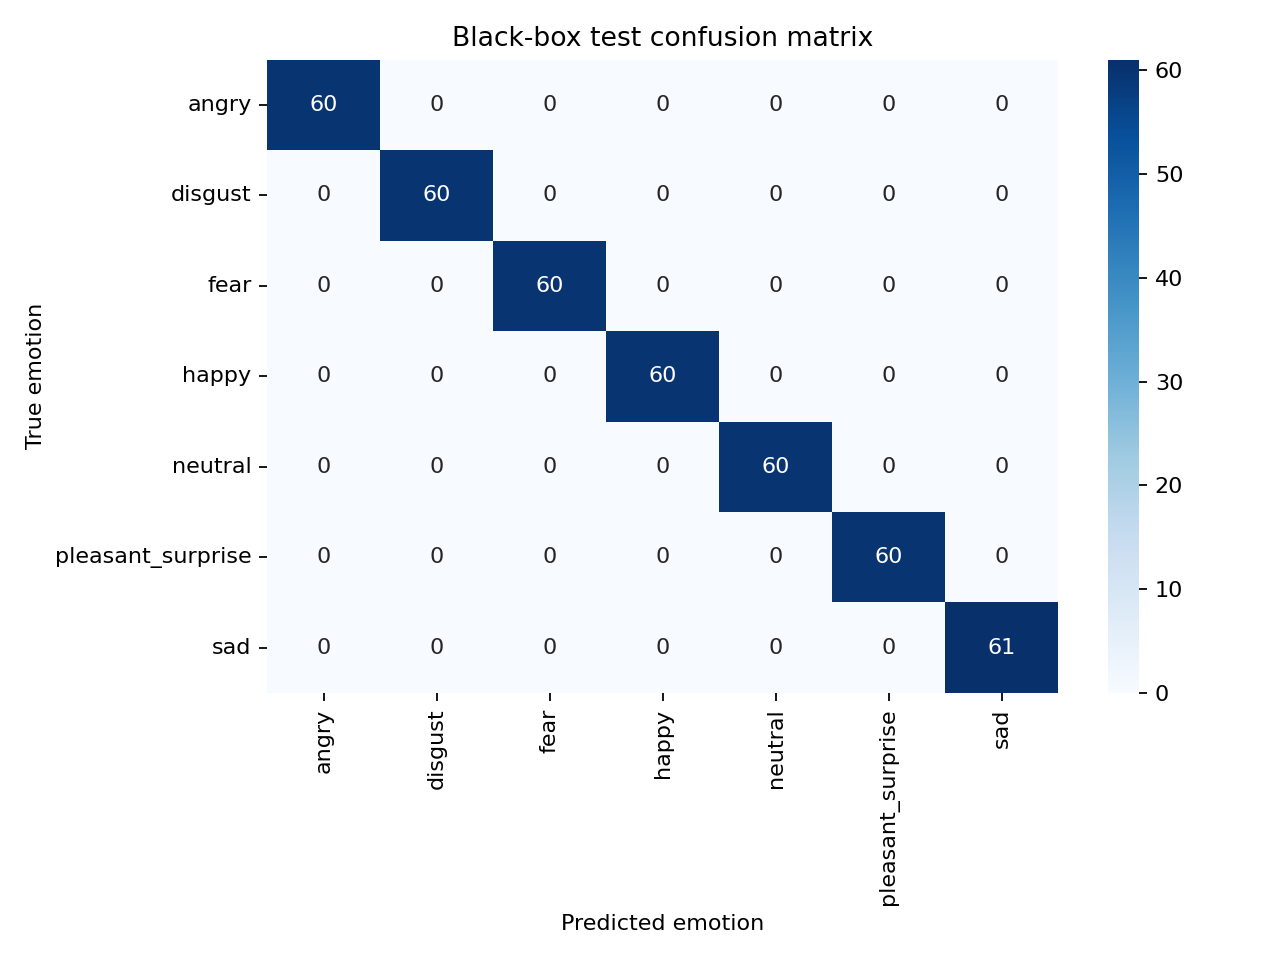

In [10]:
from IPython.display import Image, display

confusion_matrix_path = BLACK_BOX_REPORT_DIR / "test_confusion_matrix.png"
if confusion_matrix_path.exists():
    display(Image(filename=str(confusion_matrix_path)))

## 7. Visualize Embedding Spaces

Project the pooled audio encoder features and the trained black-box penultimate representations to two PCA dimensions.


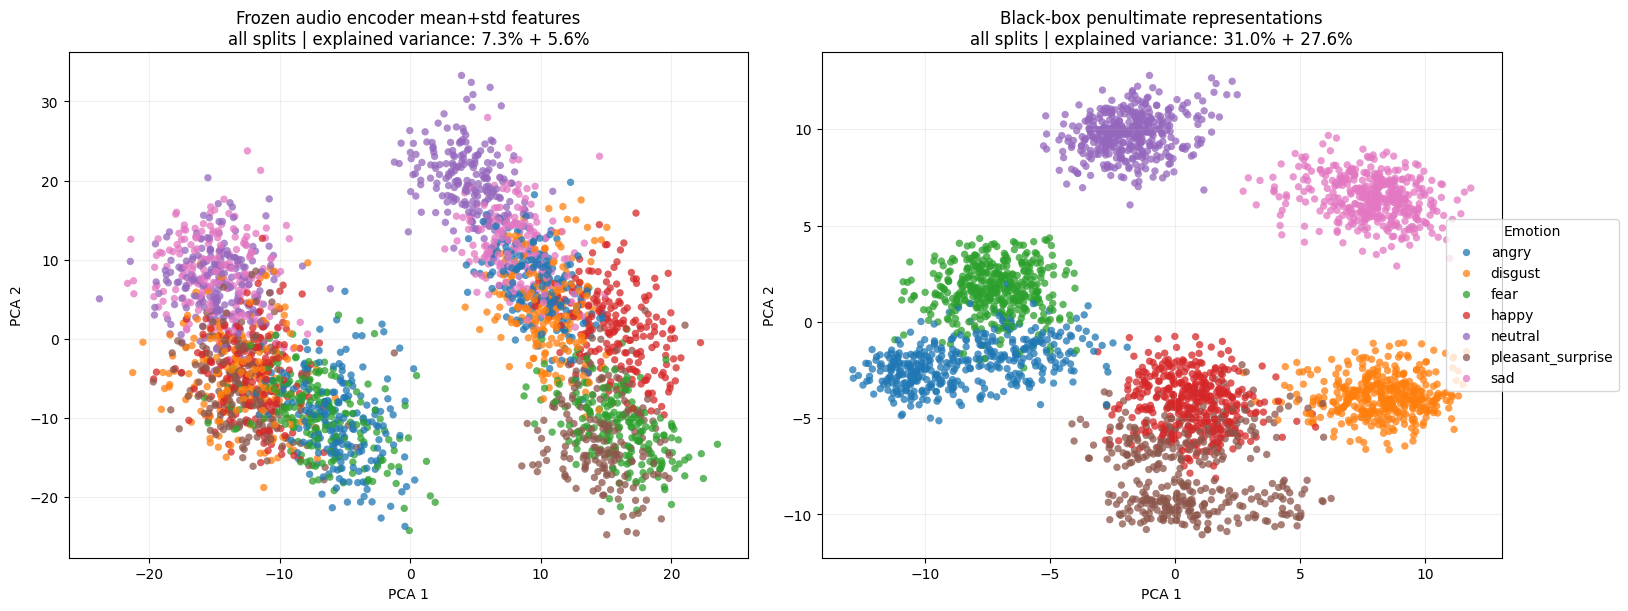

PosixPath('/Users/luigi/Documents/MSc-PoliTO/II_anno/XAI/progetto/explainable-models-for-speech-analysis/reports/blackbox_tess_wavlm_large_sample_stratified/all_embedding_pca.png')

In [11]:
from src.utils.visualize import plot_blackbox_embedding_pca

split_to_visualize = "all"

embedding_pca_result = plot_blackbox_embedding_pca(
    feature_dir=FEATURE_DIR,
    checkpoint_path=BLACK_BOX_CHECKPOINT_DIR / "best_model.pt",
    splits_csv=BLACK_BOX_CHECKPOINT_DIR / "splits.csv",
    split=split_to_visualize,
    output_path=BLACK_BOX_REPORT_DIR / f"{split_to_visualize}_embedding_pca.png",
    random_state=RANDOM_STATE
)

embedding_pca_result["output_path"]

It is interesting to note that the WavLM audio embeddings cluster into two distinct groups. Since the TESS dataset contains only two speakers, WavLM (which is trained also to extract speaker information) successfully differentiates between the two actors.

## 8. Extract Black-Box Penultimate Embeddings

Extract the representation before the final black-box classification layer and save its L2-normalized version.

In [12]:
from src.preprocessing.extract_blackbox_embeddings import extract_blackbox_penultimate_embeddings_l2

blackbox_embedding_paths = extract_blackbox_penultimate_embeddings_l2(
    feature_dir=FEATURE_DIR,
    checkpoint_path=BLACK_BOX_CHECKPOINT_DIR / "best_model.pt",
    splits_csv=BLACK_BOX_CHECKPOINT_DIR / "splits.csv",
    output_dir=BLACK_BOX_EMBEDDING_DIR,
    batch_size=256,
    overwrite=True
)

blackbox_embedding_paths

Extracting black-box penultimate embeddings:   0%|          | 0/11 [00:00<?, ?it/s]

{'features': PosixPath('/Users/luigi/Documents/MSc-PoliTO/II_anno/XAI/progetto/explainable-models-for-speech-analysis/data/features/blackbox_tess_wavlm_large_sample_stratified_penultimate_l2/features.npy'),
 'metadata': PosixPath('/Users/luigi/Documents/MSc-PoliTO/II_anno/XAI/progetto/explainable-models-for-speech-analysis/data/features/blackbox_tess_wavlm_large_sample_stratified_penultimate_l2/metadata.csv'),
 'config': PosixPath('/Users/luigi/Documents/MSc-PoliTO/II_anno/XAI/progetto/explainable-models-for-speech-analysis/data/features/blackbox_tess_wavlm_large_sample_stratified_penultimate_l2/embedding_config.json')}

## 9. Prototype Clustering Grid Search

Fit K-means on the training split only, with K clusters per emotion. Each centroid is mapped to the nearest real training sample of the same emotion, and these real prototypes are used for classification. Select K on the validation split; each vote uses all prototypes available for that K.

In [13]:
from src.data.tess import EMOTION_NAMES
from src.training.train_prototype_clustering import (
    PrototypeClusteringTrainingConfig,
    train_prototype_clustering
)

prototype_training_config = PrototypeClusteringTrainingConfig(
    embedding_dim=LAYER_DIMS[-1],
    num_classes=len(EMOTION_NAMES),
    cluster_counts=(1, 2, 3, 4, 5, 6),
    monitor_metric="macro_f1",
    random_state=RANDOM_STATE
)

prototype_training_results = train_prototype_clustering(
    embedding_dir=BLACK_BOX_EMBEDDING_DIR,
    output_dir=PROTOTYPE_CLUSTERING_CHECKPOINT_DIR,
    config=prototype_training_config
)

K=01, all prototypes=07 | val acc 1.0000, macro F1 1.0000, weighted F1 1.0000
K=02, all prototypes=14 | val acc 1.0000, macro F1 1.0000, weighted F1 1.0000
K=03, all prototypes=21 | val acc 0.9976, macro F1 0.9976, weighted F1 0.9976
K=04, all prototypes=28 | val acc 1.0000, macro F1 1.0000, weighted F1 1.0000
K=05, all prototypes=35 | val acc 1.0000, macro F1 1.0000, weighted F1 1.0000
K=06, all prototypes=42 | val acc 1.0000, macro F1 1.0000, weighted F1 1.0000

Best prototype clustering configuration
  K:           1
  Prototypes:  7 used for voting
  Validation:  accuracy 1.0000, macro F1 1.0000, weighted F1 1.0000


## 10. Evaluate Prototype Clustering Classifier

In [14]:
from src.evaluation.evaluate_prototype_clustering import evaluate_prototype_clustering
from src.evaluation.metrics import print_classification_metrics

prototype_test_metrics = evaluate_prototype_clustering(
    model_dir=PROTOTYPE_CLUSTERING_CHECKPOINT_DIR,
    embedding_dir=BLACK_BOX_EMBEDDING_DIR,
    split="test",
    output_dir=PROTOTYPE_CLUSTERING_REPORT_DIR
)

print_classification_metrics(prototype_test_metrics)

Accuracy:    0.9952
Macro F1:    0.9952
Weighted F1: 0.9952

Classification report:
          emotion precision recall f1_score  support
            angry    1.0000 1.0000   1.0000       60
          disgust    1.0000 1.0000   1.0000       60
             fear    1.0000 1.0000   1.0000       60
            happy    1.0000 0.9667   0.9831       60
          neutral    1.0000 1.0000   1.0000       60
pleasant_surprise    0.9677 1.0000   0.9836       60
              sad    1.0000 1.0000   1.0000       61


## 11. Evaluate Prototype Surrogate Fidelity

Measure how often the clustering surrogate matches the black-box predictions on the test split.

In [15]:
from src.explainability.surrogate_fidelity import print_clustering_surrogate_fidelity_accuracy

surrogate_fidelity_metrics = print_clustering_surrogate_fidelity_accuracy(
    blackbox_checkpoint_path=BLACK_BOX_CHECKPOINT_DIR / "best_model.pt",
    feature_dir=FEATURE_DIR,
    prototype_model_dir=PROTOTYPE_CLUSTERING_CHECKPOINT_DIR,
    embedding_dir=BLACK_BOX_EMBEDDING_DIR,
    splits_csv=BLACK_BOX_CHECKPOINT_DIR / "splits.csv",
    split="test"
)

Accuracy against black-box predictions: 0.9952 (419/421)


## 12. Visualize Prototype Embedding Space

Project the saved L2-normalized black-box embeddings to two PCA dimensions and highlight the prototypes of each emotion.

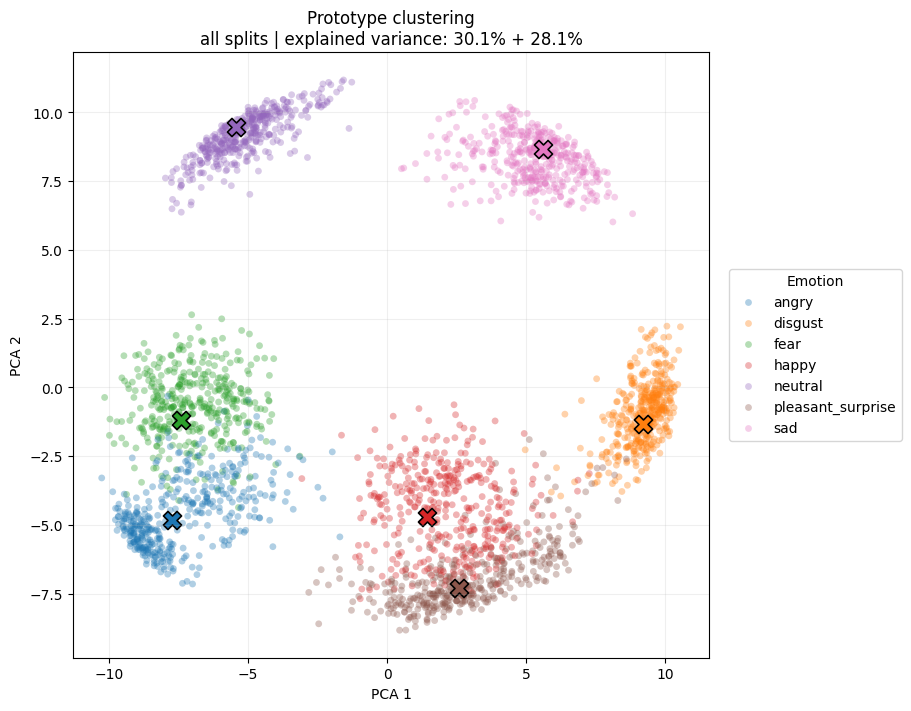

PosixPath('/Users/luigi/Documents/MSc-PoliTO/II_anno/XAI/progetto/explainable-models-for-speech-analysis/reports/prototype_clustering_blackbox_tess_wavlm_large_sample_stratified_penultimate_l2/all_prototype_embedding_pca.png')

In [16]:
from src.utils.visualize import plot_prototype_embedding_pca

prototype_pca_result = plot_prototype_embedding_pca(
    embedding_dir=BLACK_BOX_EMBEDDING_DIR,
    model_dir=PROTOTYPE_CLUSTERING_CHECKPOINT_DIR,
    split="all",
    output_path=PROTOTYPE_CLUSTERING_REPORT_DIR / "all_prototype_embedding_pca.png",
    random_state=RANDOM_STATE
)

prototype_pca_result["output_path"]

## 13. Explanation By Example - Inspect Prototype Neighbors of a Test Sample

In [17]:
import pandas as pd
from src.explainability.prototype_neighbors import (
    explain_sample_by_filename,
    print_prototype_explanation
)

# Set a TESS file name here, or leave it as None to sample a different random test example at each rerun.
SAMPLE_TO_EXPLAIN = None

prototype_explanation = explain_sample_by_filename(
    embedding_metadata=pd.read_csv(BLACK_BOX_EMBEDDING_DIR / "metadata.csv"),
    sample_to_explain=SAMPLE_TO_EXPLAIN,
    model_dir=PROTOTYPE_CLUSTERING_CHECKPOINT_DIR,
    embedding_dir=BLACK_BOX_EMBEDDING_DIR
)

print_prototype_explanation(prototype_explanation)

Sample:    OAF_rat_sad.wav
True:      sad
Predicted: sad

Class scores:
    angry: 0.1695
  disgust: 0.6006
     fear: 0.2788
    happy: 0.4180
  neutral: 0.6366
  pleasant_surprise: 0.2727
      sad: 0.9744

All 7 voting prototypes, sorted by similarity:
  #01     sad | sim 0.9744 | OAF_goose_sad.wav
  #02 neutral | sim 0.6366 | YAF_luck_neutral.wav
  #03 disgust | sim 0.6006 | OAF_south_disgust.wav
  #04   happy | sim 0.4180 | YAF_five_happy.wav
  #05    fear | sim 0.2788 | OAF_five_fear.wav
  #06 pleasant_surprise | sim 0.2727 | OAF_join_ps.wav
  #07   angry | sim 0.1695 | YAF_laud_angry.wav


We can listen to the test sample and its nearest prototypes (medoids).

In [18]:
from IPython.display import Audio, display, Markdown

sample_file = prototype_explanation["file_name"]
display(Markdown(f"### Sample: `{sample_file}`"))
display(Audio(filename=str(AUDIO_DIR / sample_file)))

display(Markdown("### Top prototypes"))
for prototype in prototype_explanation["top_prototypes"]:
    prototype_file = prototype.get("prototype_file_name")

    display(Markdown(
        f"**#{prototype['rank']} | {prototype['prototype_emotion']} | "
        f"similarity: {prototype['similarity']:.4f}**  \n"
        f"`{prototype_file}`"
    ))
    display(Audio(filename=str(AUDIO_DIR / prototype_file)))

### Sample: `OAF_rat_sad.wav`

### Top prototypes

**#1 | sad | similarity: 0.9744**  
`OAF_goose_sad.wav`

**#2 | neutral | similarity: 0.6366**  
`YAF_luck_neutral.wav`

**#3 | disgust | similarity: 0.6006**  
`OAF_south_disgust.wav`

**#4 | happy | similarity: 0.4180**  
`YAF_five_happy.wav`

**#5 | fear | similarity: 0.2788**  
`OAF_five_fear.wav`

**#6 | pleasant_surprise | similarity: 0.2727**  
`OAF_join_ps.wav`

**#7 | angry | similarity: 0.1695**  
`YAF_laud_angry.wav`